# Deep Learning: AG News

**Author:** Belal Nwiran

**Dataset:** [AG News Classification Dataset](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset)

This project trains a Transformer text classifier on the AG News dataset. The task is to predict one of four news topics (World, Sports, Business, Sci/Tech) from an article's title and description. It compares a baseline model with one modified version, changing exactly one aspect.

**Source:** Kaggle (link above), train.csv (120,000 rows) and test.csv (7,600 rows), downloaded on 2026-10-01, unmodified.

# Setup

In [28]:
import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import re
import seaborn as sns
import time
import torch
import torch.nn as nn

from collections import Counter
from torch.utils.data import Dataset, DataLoader
from typing import Optional

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


All random seeds (Python, NumPy, PyTorch) are set to 42 so results can be repeated. Training runs on a GPU (CUDA) when one is available.

# Dataset Inspection

In [3]:
train_full = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train:", train_full.shape, "| Test:", test_df.shape)
print(train_full.dtypes)

CLASS_NAMES = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}

Train: (120000, 3) | Test: (7600, 3)
Class Index    int64
Title            str
Description      str
dtype: object


In [4]:
train_full.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
# Class samples
for c, name in CLASS_NAMES.items():
    print(f"\n=== {c}: {name} ===")
    sample = train_full[train_full["Class Index"] == c].sample(2, random_state=SEED)
    for _, r in sample.iterrows():
        print("-", r["Title"])
        print("   ", r["Description"][:200])


=== 1: World ===
- Explosion Rocks Baghdad Neighborhood
    BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnes
- BBC reporters' log
    BBC correspondents record events in the Middle East and their thoughts as the funeral of the Palestinian leader Yasser Arafat takes place.

=== 2: Sports ===
- Second Andre win in a row boosts US gold medal hopes
    Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wednesday by narrowly beating Cuba #39;s Yordani Despaigne to a
- NFL Game Summary - Kansas City at New Orleans
    Tight end Tony Gonzalez caught six passes for 71 yards for the Chiefs, who have scored 38 points on their initial drive of the game this season...Safety Jay Bellamy and Fakhir Brown each made nine tac

=== 3: Business ===
- US house sales fall

## Dataset overview

The training file has 120,000 rows and the test file has 7,600 rows. Each row has a class label (`Class Index`, values 1 to 4), a `Title`, and a `Description`. Labels are mapped to topics as 1 = World, 2 = Sports, 3 = Business, 4 = Sci/Tech. The sample articles above match their labels.

In [6]:
print("\nMissing values (train):\n", train_full.isna().sum())
print("Missing values (test):\n", test_df.isna().sum())
print("Duplicate rows (train):", train_full.duplicated().sum())
print("Duplicate rows (test):", test_df.duplicated().sum())


Missing values (train):
 Class Index    0
Title          0
Description    0
dtype: int64
Missing values (test):
 Class Index    0
Title          0
Description    0
dtype: int64
Duplicate rows (train): 0
Duplicate rows (test): 0


## Data quality checks

- There are no missing values and no duplicate rows in either the training or the test file.
- Some texts contain encoded characters, such as `#39;` for an apostrophe and `amp;` for an ampersand. They appear in both training and test text, so keeping them gives every model the same input. They will shown up as extra tokens in the vocabulary..

count    120000.000000
mean         37.844617
std          10.088702
min           4.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: n_words, dtype: float64
0.95    53.0
0.99    70.0
Name: n_words, dtype: float64


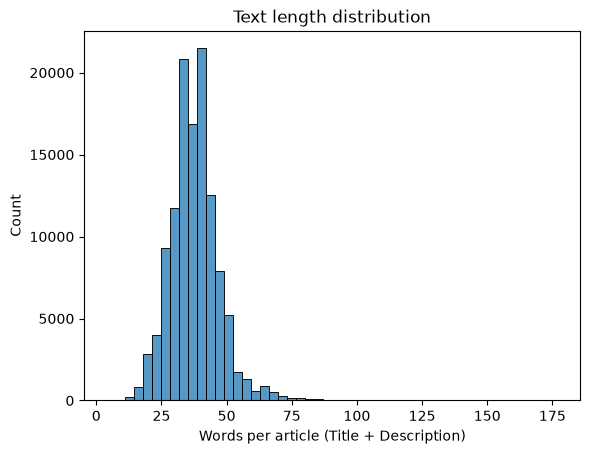

In [7]:
for d in (train_full, test_df):
    d["text"] = d["Title"].fillna("") + " " + d["Description"].fillna("")

train_full["n_words"] = train_full["text"].str.split().str.len()
print(train_full["n_words"].describe())
print(train_full["n_words"].quantile([0.95, 0.99]))

sns.histplot(train_full["n_words"], bins=50)
plt.xlabel("Words per article (Title + Description)")
plt.title("Text length distribution")
plt.show()

## Text length

Title and description are joined into one text. Articles are short: the mean is 37.8 words, the median is 37, the 95th percentile is 53, the 99th percentile is 70, and the longest is 177. The maximum sequence length for the model is chosen from these numbers in the preprocessing section.

In [8]:
prefix = train_full["Description"].str.extract(r"^([^-]{2,30}) - ", expand=False)
print(prefix.value_counts().head(15))
print("Rows with a prefix:", prefix.notna().sum(), "of", len(train_full))

Description
AP                          7706
Reuters                     4223
 NEW YORK (Reuters)         2048
AFP                         1955
 LONDON (Reuters)            596
NEW YORK                     586
 WASHINGTON (Reuters)        550
Canadian Press               451
WASHINGTON                   414
 TOKYO (Reuters)             411
 CHICAGO (Reuters)           266
NewsFactor                   253
 SAN FRANCISCO (Reuters)     242
 ATHENS (Reuters)            231
washingtonpost.com           206
Name: count, dtype: int64
Rows with a prefix: 32246 of 120000


In [9]:
def agency(text: str) -> Optional[str]:
    head = text[:60]
    for name in ["Reuters", "AP", "AFP", "Canadian Press", "NewsFactor", "washingtonpost.com"]:
        if re.search(rf"\b{re.escape(name)}\b", head):
            return name
    return None

train_full["agency"] = train_full["Description"].map(agency)
test_df["agency"] = test_df["Description"].map(agency)
print(train_full["agency"].value_counts(dropna=False))

ct = pd.crosstab(train_full["agency"], train_full["Class Index"])
print("\n", ct)
print("\n", ct.div(ct.sum(axis=1), axis=0).round(2))  # share of each agency per class

agency
NaN                   95746
Reuters               12577
AP                     8406
AFP                    2497
Canadian Press          314
NewsFactor              253
washingtonpost.com      207
Name: count, dtype: int64

 Class Index            1     2     3     4
agency                                    
AFP                 1810   153   327   207
AP                  2961  3122   283  2040
Canadian Press       313     0     0     1
NewsFactor             0     0     4   249
Reuters             3842  1408  5423  1904
washingtonpost.com    17     0     0   190

 Class Index            1     2     3     4
agency                                    
AFP                 0.72  0.06  0.13  0.08
AP                  0.35  0.37  0.03  0.24
Canadian Press      1.00  0.00  0.00  0.00
NewsFactor          0.00  0.00  0.02  0.98
Reuters             0.31  0.11  0.43  0.15
washingtonpost.com  0.08  0.00  0.00  0.92


## News-agency tags

About 20% of training rows (24,254 of 120,000) show a news-agency tag within the first 60 characters of the description, found with a whole-word match (Reuters is checked first).

Three small tags are strongly one-sided: Canadian Press (314 rows, 100% World), NewsFactor (253 rows, 98% Sci/Tech), and washingtonpost.com (207 rows, 92% Sci/Tech). Together they cover about 0.6% of the data. AFP (2,497 rows) leans World at 72%. Most tagged rows come from Reuters (12,577) and AP (8,406), which appear in several classes but not evenly: Reuters is 43% Business, and AP is only 3% Business.

The shortcut risk looks mild, but a model could still learn to use the tag instead of the topic. The raw text is kept for all models so the comparison stays controlled. This is recorded as a limitation, and accuracy on tagged and untagged articles will be compared after training.

In [10]:
# Data split
train_full["label"] = train_full["Class Index"] - 1
test_df["label"] = test_df["Class Index"] - 1

val_df = train_full.groupby("label", group_keys=False).sample(frac=0.1, random_state=SEED)
train_df = train_full.drop(val_df.index).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df), "| Validation:", len(val_df))
print(train_df["label"].value_counts().sort_index())
print(val_df["label"].value_counts().sort_index())
print(test_df["label"].value_counts().sort_index())

Train: 108000 | Validation: 12000
label
0    27000
1    27000
2    27000
3    27000
Name: count, dtype: int64
label
0    3000
1    3000
2    3000
3    3000
Name: count, dtype: int64
label
0    1900
1    1900
2    1900
3    1900
Name: count, dtype: int64


## Train / validation / test split

Labels are converted to 0–3. A stratified 10% sample of `train.csv` (seed 42) is held out as the validation set. This gives 108,000 training rows (27,000 per class) and 12,000 validation rows (3,000 per class). The test set has 1,900 per class, so both are perfectly balanced. The official `test.csv` is not used until the final evaluation.

# Tokenization

In [12]:
TOKEN_RE = re.compile(r"\w+|[^\w\s]")

def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(text.lower())

train_tokens = [tokenize(t) for t in train_df["text"]]
val_tokens = [tokenize(t) for t in val_df["text"]]
test_tokens = [tokenize(t) for t in test_df["text"]]

print(train_df["text"].iloc[0])
print(train_tokens[0])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
['wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short', '-', 'sellers', ',', 'wall', 'street', "'", 's', 'dwindling', '\\', 'band', 'of', 'ultra', '-', 'cynics', ',', 'are', 'seeing', 'green', 'again', '.']


## Preprocessing

### Vocabulary
#### Size

In [19]:
# Choosing the reasonable vocabulary size
total_tokens = sum(counter.values())
for size in [10000, 20000, 30000, 40000, 50000, len(counter)]:
    covered = sum(c for _, c in counter.most_common(size))
    print(f"Vocab {size:>6}: covers {covered / total_tokens:.2%} of training tokens")

Vocab  10000: covers 94.86% of training tokens
Vocab  20000: covers 97.98% of training tokens
Vocab  30000: covers 99.04% of training tokens
Vocab  40000: covers 99.51% of training tokens
Vocab  50000: covers 99.75% of training tokens
Vocab  62586: covers 100.00% of training tokens


The training text has 62,586 unique tokens. The vocabulary keeps the 30,000 most frequent ones (plus \<pad> and \<unk>), which covers 99.04% of training tokens. Going from 30,000 to 40,000 words adds only 0.5 percentage points of coverage, and the words beyond 30,000 appear only a few times each, so they would get weak embeddings. The same vocabulary is used for every model. The vocabulary is built from the training split only.

#### Building

In [13]:
# Vocabulary
PAD, UNK = "<pad>", "<unk>"
MAX_VOCAB = 30000

counter = Counter(tok for toks in train_tokens for tok in toks)
print("Unique tokens in train:", len(counter))

itos = [PAD, UNK] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
stoi = {w: i for i, w in enumerate(itos)}
PAD_ID, UNK_ID = stoi[PAD], stoi[UNK]
print("Vocabulary size:", len(itos))

Unique tokens in train: 62586
Vocabulary size: 30000


#### Max. Length

In [15]:
# Token length distribution (decides MAX_LEN)
lengths = pd.Series([len(t) for t in train_tokens])
print(lengths.describe())
print("\n", lengths.quantile([0.95, 0.99, 0.995]))

# Share of tokens mapped to <unk>
def unk_rate(token_lists):
    total = sum(len(t) for t in token_lists)
    unk = sum(1 for t in token_lists for w in t if w not in stoi)
    return unk / total

print(f"\nUNK rate - train: {unk_rate(train_tokens):.2%} | validation: {unk_rate(val_tokens):.2%}")

count    108000.000000
mean         47.251991
std          16.787887
min           6.000000
25%          38.000000
50%          45.000000
75%          53.000000
max         314.000000
dtype: float64

 0.950     74.0
0.990    108.0
0.995    124.0
dtype: float64

UNK rate - train: 0.96% | validation: 1.30%


After tokenization, the median article has 45 tokens and the 99th percentile is 108 (maximum 314). The maximum sequence length is set to 128 tokens, which truncates less than 1% of training articles. The rate is 0.96% on the training split and 1.30% on the validation split, so the 30,000-word vocabulary generalizes well to unseen text.

In [21]:
MAX_LEN = 128

def encode(tokens: list[str], max_len: int = MAX_LEN) -> list[int]:
    ids = [stoi.get(w, UNK_ID) for w in tokens[:max_len]]
    return ids + [PAD_ID] * (max_len - len(ids))

print(encode(train_tokens[0]))

[464, 474, 2, 1684, 14480, 125, 80, 3, 874, 17, 34, 18, 34, 5, 774, 5, 8312, 4, 464, 400, 19, 12, 9777, 21, 2857, 8, 5839, 5, 24237, 4, 55, 4123, 826, 351, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Datasets and DataLoaders

In [23]:
class NewsDataset(Dataset):
    def __init__(self, token_lists, labels):
        self.x = torch.tensor([encode(t) for t in token_lists], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

BATCH_SIZE = 128

train_ds = NewsDataset(train_tokens, train_df["label"].values)
val_ds = NewsDataset(val_tokens, val_df["label"].values)
test_ds = NewsDataset(test_tokens, test_df["label"].values)

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape)
print(len(train_ds), len(val_ds), len(test_ds))

torch.Size([128, 128]) torch.Size([128])
108000 12000 7600


# Transfomers

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]


class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2,
                 dim_ff=256, dropout=0.1, num_classes=4, pad_id=0):
        super().__init__()
        self.pad_id = pad_id
        self.d_model = d_model
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(
            d_model, nhead, dim_ff, dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(
            layer, num_layers, enable_nested_tensor=False
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        pad_mask = x == self.pad_id                      # True where padding
        h = self.embed(x) * math.sqrt(self.d_model)
        h = self.pos(h)
        h = self.encoder(h, src_key_padding_mask=pad_mask)
        keep = (~pad_mask).unsqueeze(-1).float()         # 1 for real tokens
        pooled = (h * keep).sum(dim=1) / keep.sum(dim=1).clamp(min=1)
        return self.fc(self.dropout(pooled))             # raw logits

In [26]:
# Sanity Check
model = TransformerClassifier(vocab_size=len(itos), pad_id=PAD_ID).to(device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

model.eval()
with torch.no_grad():
    logits = model(xb.to(device))
print(logits.shape)

Parameters: 4105476
torch.Size([128, 4])


## Baseline model: Transformer encoder

The baseline is a small encoder-only Transformer built in PyTorch. An encoder is enough because the task is to classify a whole article, so no decoder is needed (Vaswani et al., 2017).

**Architecture**
- **Embedding layer:** turns each token ID into a 128-dimensional vector. Padding tokens are ignored.
- **Positional encoding:** a fixed sine/cosine signal is added to the embeddings, because self-attention alone does not know word order.
- **Encoder:** 2 `TransformerEncoderLayer` blocks, each with 4 attention heads (32 dimensions per head) and a feed-forward layer of size 256. The feed-forward layers use ReLU, and the layers use dropout of 0.1 and layer normalization (PyTorch defaults).
- **Padding mask:** padded positions are ignored in attention and in pooling, so padding does not change the result.
- **Pooling:** the output vectors of the real tokens are averaged into one vector per article. This is simpler than adding a special classification token.
- **Output:** a linear layer gives 4 raw scores (logits), one per topic. No softmax is added, because `CrossEntropyLoss` applies it internally.

The model has 4,105,476 parameters. About 3.84 million of them are in the embedding table (30,000 words × 128), so the Transformer layers themselves are small. The hyperparameters are a reasonable starting point, not tuned.

In [27]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        n += len(yb)
    return total_loss / n, correct / n


def train_model(model, train_loader, val_loader, epochs=10, lr=5e-4, weight_decay=0.01):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        model.train()
        run_loss, correct, n = 0.0, 0, 0
        t0 = time.time()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            run_loss += loss.item() * len(yb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += len(yb)

        val_loss, val_acc = evaluate(model, val_loader)
        history["train_loss"].append(run_loss / n)
        history["train_acc"].append(correct / n)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch:2d} | train loss {run_loss/n:.4f} acc {correct/n:.4f} | "
              f"val loss {val_loss:.4f} acc {val_acc:.4f} | {time.time()-t0:.0f}s")

    model.load_state_dict(best_state)
    return history

In [29]:
def plot_history(hist, title):
    epochs = range(1, len(hist["train_loss"]) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(epochs, hist["train_loss"], label="train")
    ax[0].plot(epochs, hist["val_loss"], label="validation")
    ax[0].set_title(f"{title}: loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
    ax[1].plot(epochs, hist["train_acc"], label="train")
    ax[1].plot(epochs, hist["val_acc"], label="validation")
    ax[1].set_title(f"{title}: accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

## Baseline training setup

- **Loss:** cross-entropy, the standard loss for multi-class classification.
- **Optimizer:** AdamW, learning rate 5e-4, weight decay 0.01.
- **Training:** 10 epochs, batch size 128, gradient clipping at 1.0 to protect against sudden loss spikes.
- **Model selection:** after each epoch the model is evaluated on the validation set, and the weights with the best validation accuracy are kept. The test set is not used during training.
- **Reproducibility:** seed 42 is used for model initialization and for the training data order.
- **Progress:** loss and accuracy for training and validation are printed each epoch and plotted below.

In [31]:
torch.manual_seed(SEED)
g.manual_seed(SEED)   # resets the training shuffle order
baseline = TransformerClassifier(vocab_size=len(itos), pad_id=PAD_ID).to(device)
baseline_hist = train_model(baseline, train_loader, val_loader, epochs=10)

Epoch  1 | train loss 0.6506 acc 0.7503 | val loss 0.4400 acc 0.8475 | 12s
Epoch  2 | train loss 0.3871 acc 0.8637 | val loss 0.3672 acc 0.8734 | 15s
Epoch  3 | train loss 0.3148 acc 0.8903 | val loss 0.3222 acc 0.8905 | 15s
Epoch  4 | train loss 0.2739 acc 0.9055 | val loss 0.3192 acc 0.8908 | 15s
Epoch  5 | train loss 0.2468 acc 0.9142 | val loss 0.2886 acc 0.9032 | 15s
Epoch  6 | train loss 0.2231 acc 0.9225 | val loss 0.2907 acc 0.9049 | 15s
Epoch  7 | train loss 0.2043 acc 0.9289 | val loss 0.2847 acc 0.9069 | 16s
Epoch  8 | train loss 0.1896 acc 0.9347 | val loss 0.2813 acc 0.9111 | 17s
Epoch  9 | train loss 0.1748 acc 0.9383 | val loss 0.2899 acc 0.9107 | 15s
Epoch 10 | train loss 0.1617 acc 0.9435 | val loss 0.2978 acc 0.9104 | 16s


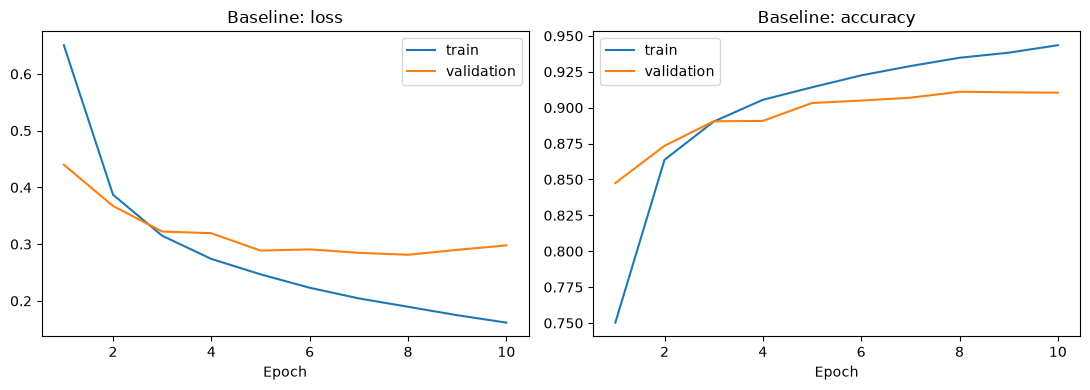

In [32]:
plot_history(baseline_hist, "Baseline")

The weights from the best epoch (**epoch 8**) are kept as it gave the best accuracy.